# Electricity Price Spread Direction Prediction  
---

## 1. Background

Companies with high electricity consumption can reduce costs by optimizing how much electricity they commit to buying in the day-ahead market versus settling in the real-time market. Each morning, companies submit hourly electricity demand for the next day, while deviations between declared and actual consumption are settled later at the real-time price.

Because day-ahead and real-time prices often differ, <font color='blue'> predicting the direction of the price spread can support better electricity purchasing decisions </font>. If the real-time price is expected to be lower than the day-ahead price, a company may reduce its day-ahead commitment and settle more usage in the real-time market. If the real-time price is expected to be higher, it may commit more in the day-ahead market to <font color='blue'>reduce price risk</font>.

At the time of submission, both final day-ahead and real-time prices are uncertain. Therefore, this project focuses on predicting the hourly direction of the price spread: <font color='red'>**whether the real-time price will be lower than the day-ahead price**</font>.

---


## 2. Data Overview

The dataset contains hourly electricity-market observations from **April to August 2025** for a specific region. Each row represents one hourly trading period.

The available data include:

- Day-ahead forecast variables for the execution day
- Historical real-time market variables available before the decision time
- Historical day-ahead price information
- A binary target label indicating the direction of the price spread

In this project, the main prediction task is to use boundary condition data and historical market information to predict the direction of the electricity price spread.

---

### 2.1 Target Definition

The label column is **"Bet on Low Price (搏低价)."**

| Target | Meaning | Trading Interpretation |
|---|---|---|
| `1` | Real-time price < Day-ahead price | Real-time electricity is cheaper; reducing day-ahead commitment may lower costs |
| `0` | Real-time price > Day-ahead price | Day-ahead electricity is cheaper; increasing day-ahead commitment may reduce price risk |

The model is trained as a binary classification problem, where the goal is to predict the probability that:

**Real-time price < Day-ahead price**

---

### 2.2 Input Features

The input variables are grouped by when they are available relative to the strategy execution day.

| Feature Group | Timing | Description | Example Features |
|---|---|---|---|
| Day-ahead forecast variables | `T` | Forecast information for the execution day | `PV_DayAhead_T`, `ProvincialLoad_DayAhead_T`, `BiddingSpace_DayAhead_T`, `Wind_DayAhead_T` |
| Real-time historical variables | `T-2` | Real-time market information available before the decision is made | `PV_RealTime_T_minus_2`, `ProvincialLoad_RealTime_T_minus_2`, `BiddingSpace_RealTime_T_minus_2`, `ClearingPrice_RealTime_T_minus_2` |
| Day-ahead historical price | `T-1` | Most recent known day-ahead price before the execution day | `ClearingPrice_DayAhead_T_minus_1` |
| Time features | Current timestamp | Calendar and hourly information used to capture intraday patterns | `datetime` |


The project uses the following timing convention:

- **T**: Strategy execution day  
- **T-1**: One day before the execution day  
- **T-2**: Two days before the execution day  

    For example, if the company is making a strategy decision on **April 1, 2025** for electricity use on **April 2, 2025**, then:

    - **April 2** is the execution day, or **T**
    - Day-ahead forecast variables for April 2 are available
    - The final April 2 day-ahead and real-time prices are not yet known
    - Real-time historical variables are only available up to earlier dates, such as **T-2**
    - The most recent known day-ahead price is from **T-1**

This timing setup is important because it prevents the model from using information that would not have been available at the actual decision time.

---

## 3. EDA

In [1]:
# Load Data
import pandas as pd
train_raw = pd.read_csv("train.csv", parse_dates=True, index_col=0)
labels = pd.read_csv("labels.csv", parse_dates=True, index_col=0)
train_raw.head(3)

,光伏_日前(T),省调负荷_日前(T),竞价空间_日前(T),联络线计划日_日前(T),非市场化机组出力_日前(T),风力_日前(T),光伏_实时(T-2),省调负荷_实时(T-2),竞价空间_实时(T-2),联络线计划日_实时(T-2),非市场化机组出力_实时(T-2),风力_实时(T-2),出清价格_实时(T-2),出清价格_日前(T-1)
datetime,,,,,,,,,,,,,,
2025-04-03 00:00:00,18.0,57568.28,39575.94,11820.50,1582.0,4571.83,-11.4425,57369.75,24508.56,11408.44,1547.299,19916.90,256.95,328.66
2025-04-03 01:00:00,18.0,56082.60,38295.34,11451.50,1582.0,4735.77,-11.3025,56154.64,23021.91,11469.57,1548.051,20126.41,236.16,329.84
2025-04-03 02:00:00,18.0,55159.24,37170.36,11445.25,1582.0,4943.62,-11.4000,55059.51,21958.33,11470.74,1550.870,20090.98,172.70,347.54


In [2]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2856 entries, 2025-04-03 00:00:00 to 2025-07-31 23:00:00
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   光伏_日前(T)          2856 non-null   float64
 1   省调负荷_日前(T)        2856 non-null   float64
 2   竞价空间_日前(T)        2856 non-null   float64
 3   联络线计划日_日前(T)      2856 non-null   float64
 4   非市场化机组出力_日前(T)    2856 non-null   float64
 5   风力_日前(T)          2856 non-null   float64
 6   光伏_实时(T-2)        2856 non-null   float64
 7   省调负荷_实时(T-2)      2856 non-null   float64
 8   竞价空间_实时(T-2)      2856 non-null   float64
 9   联络线计划日_实时(T-2)    2856 non-null   float64
 10  非市场化机组出力_实时(T-2)  2856 non-null   float64
 11  风力_实时(T-2)        2856 non-null   float64
 12  出清价格_实时(T-2)      2856 non-null   float64
 13  出清价格_日前(T-1)      2856 non-null   float64
dtypes: float64(14)
memory usage: 334.7 KB


In [3]:
train_raw.describe()

,光伏_日前(T),省调负荷_日前(T),竞价空间_日前(T),联络线计划日_日前(T),非市场化机组出力_日前(T),风力_日前(T),光伏_实时(T-2),省调负荷_实时(T-2),竞价空间_实时(T-2),联络线计划日_实时(T-2),非市场化机组出力_实时(T-2),风力_实时(T-2),出清价格_实时(T-2),出清价格_日前(T-1)
count,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000,2856.000000
mean,5762.689895,64608.476551,29411.978971,20015.585298,1591.329314,7826.892875,4238.089919,64069.667108,31511.028564,19745.938211,1585.481789,6989.128822,275.218438,276.150434
std,6926.159936,13217.418535,15585.784153,4815.089848,91.010608,4674.903280,5178.350583,13148.900989,12354.476677,4792.747103,94.836043,4756.825171,220.393453,215.002909
min,0.000000,26430.440000,-18972.150000,10361.000000,1254.200000,473.160000,-17.805000,28955.710000,6572.180000,10281.250000,1251.348000,28.657500,-95.100000,-100.000000
25%,13.630000,55174.417500,21164.360000,16681.437500,1609.000000,4302.597500,-12.875625,54973.195000,22072.507500,16128.592500,1580.723500,3334.024250,70.355000,100.000000
50%,1268.545000,62822.720000,30721.330000,19574.805000,1619.600000,6804.545000,1152.376500,62428.240000,30944.225000,19211.580000,1620.278000,5847.998500,352.030000,346.435000
75%,12039.132500,73735.912500,39344.765000,23621.875000,1635.500000,10794.395000,7829.577500,72624.987500,39436.452500,23197.600000,1630.419000,9872.337000,438.267500,440.365000
max,20975.210000,109250.300000,71545.300000,34155.750000,1684.000000,21016.720000,20468.640000,105434.100000,69410.620000,34108.590000,1646.518000,21990.930000,1237.600000,1492.970000


In [4]:
labels.describe()

,搏低价
count,2856.000000
mean,0.492997
std,0.500039
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [5]:
import pandas as pd
import numpy as np

# Rename Columns to English
col_map = {
    "光伏_日前(T)": "PV_DayAhead_T",
    "省调负荷_日前(T)": "ProvincialLoad_DayAhead_T",
    "竞价空间_日前(T)": "BiddingSpace_DayAhead_T",
    "联络线计划日_日前(T)": "InterconnectionPlan_DayAhead_T",
    "非市场化机组出力_日前(T)": "NonMarketUnitOutput_DayAhead_T",
    "风力_日前(T)": "Wind_DayAhead_T",
    "光伏_实时(T-2)": "PV_RealTime_T_minus_2",
    "省调负荷_实时(T-2)": "ProvincialLoad_RealTime_T_minus_2",
    "竞价空间_实时(T-2)": "BiddingSpace_RealTime_T_minus_2",
    "联络线计划日_实时(T-2)": "Interconnection_RealTime_T_minus_2",
    "非市场化机组出力_实时(T-2)": "NonMarketUnitOutput_RealTime_T_minus_2",
    "风力_实时(T-2)": "Wind_RealTime_T_minus_2",
    "出清价格_实时(T-2)": "ClearingPrice_RealTime_T_minus_2",
    "出清价格_日前(T-1)": "ClearingPrice_DayAhead_T_minus_1"
}

train_eda = train_raw.rename(columns=col_map)
labels = labels.rename(columns={"搏低价": "BetLowPrice"})

# Join labels
train_eda["target"] = labels["BetLowPrice"]

# Add time columns
train_eda["hour"] = train_eda.index.hour
train_eda["dayofweek"] = train_eda.index.dayofweek
train_eda["is_weekend"] = train_eda.index.dayofweek.isin([5, 6]).astype(int)
train_eda["month"] = train_eda.index.month
train_eda["day"] = train_eda.index.day

# Encode hour as cyclical data (cuz in reality 23:00 and 00:00 are adjacent in time)
## electricity is strongly hourly
## many effects are not global; they are hour-dependent
train_eda["hour_sin"] = np.sin(2 * np.pi * train_eda["hour"] / 24)
train_eda["hour_cos"] = np.cos(2 * np.pi * train_eda["hour"] / 24)
# Encode 

train_eda[["hour_sin","hour_cos","hour", "dayofweek", "is_weekend", "month", "day"]].head()

,hour_sin,hour_cos,hour,dayofweek,is_weekend,month,day
datetime,,,,,,,
2025-04-03 00:00:00,0.000000,1.000000,0,3,0,4,3
2025-04-03 01:00:00,0.258819,0.965926,1,3,0,4,3
2025-04-03 02:00:00,0.500000,0.866025,2,3,0,4,3
2025-04-03 03:00:00,0.707107,0.707107,3,3,0,4,3
2025-04-03 04:00:00,0.866025,0.500000,4,3,0,4,3


### 3.1 EDA: Target behavior by time
Questions:
- Are some hours much more likely to be BetLowPrice = 1?
- Does the rate drift from April to July?
- Are there regime changes?

#### 3.1.1 Target mean by hour

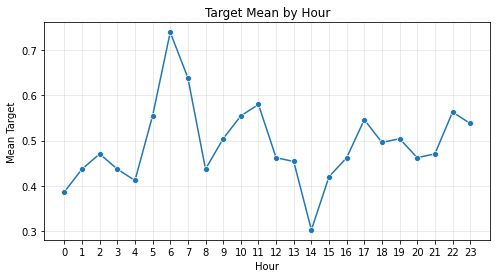

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

target_by_hour = train_eda.groupby("hour")["target"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=target_by_hour, x="hour", y="target", marker="o")
plt.title("Target Mean by Hour")
plt.xlabel("Hour")
plt.ylabel("Mean Target")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

Hours more likely to BetLowPrice: 5, 6, 7, 10, 11, 12, 22, 23

#### 3.1.2 Target mean by day of week

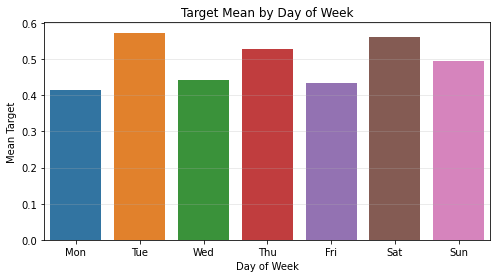

In [7]:
target_by_dow = train_eda.groupby("dayofweek")["target"].mean().reset_index()

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 4))
sns.barplot(data=target_by_dow, x="dayofweek", y="target")
plt.title("Target Mean by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Target")
plt.xticks(ticks=range(7), labels=dow_labels)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

No obvious relationship between Target and day of week. Tuesday, Thursday and Saturday (and maybe Sunday) are slightly higher than the other days.

#### 3.1.3 Target mean by month

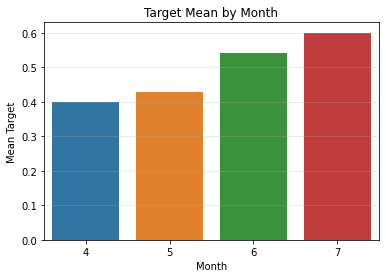

In [8]:
target_by_month = train_eda.groupby("month")["target"].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=target_by_month, x="month", y="target")
plt.title("Target Mean by Month")
plt.xlabel("Month")
plt.ylabel("Mean Target")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

More likely to bet low price in later months.

### 3.2 EDA: Feature Correlation

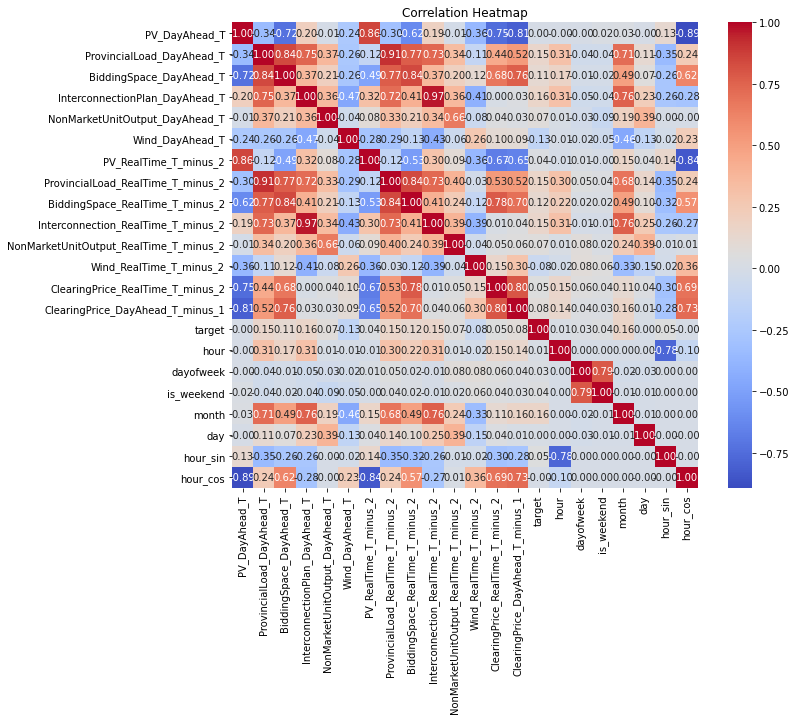

In [9]:
from IPython.display import display, HTML
display(HTML("<style>.output_wrapper, .output {height:auto !important; max-height:none !important;}</style>"))


import matplotlib.pyplot as plt
import seaborn as sns

# correlation matrix
corr = train_eda.corr(numeric_only=True)

# plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

##### Correlation Summary
- The target variable shows relatively weak linear correlation with individual raw features, suggesting that the price-spread direction is not explained by a single variable alone.

- Several market variables are strongly correlated with each other, especially between day-ahead forecasts and corresponding real-time historical variables. For example, forecasted and historical load, bidding space, PV generation, and interconnection variables show clear relationships.

- `BiddingSpace_DayAhead_T` is strongly related to load and price variables, making it a useful first-pass proxy for system tightness or market balance.

- `ProvincialLoad_DayAhead_T` is highly correlated with several demand and market-balance variables, consistent with the idea that load pressure is an important driver of electricity price behavior.

- `PV_DayAhead_T` and `hour_cos` show strong correlation, reflecting the daily solar generation cycle. This supports including time-based features such as `hour`, `hour_sin`, and `hour_cos`.

- Historical price variables, including `ClearingPrice_RealTime_T_minus_2` and `ClearingPrice_DayAhead_T_minus_1`, are correlated with several system variables and may capture recent market regimes or price persistence.

- Because many predictors are correlated, tree-based models such as LightGBM can be useful for capturing nonlinear interactions while reducing the need to manually remove every correlated feature.

### 3.3 EDA: feature distributions by target
- Does separation happen only during certain hours?
- Are there threshold-like effects?
- Are some variables only useful in solar hours?

Based on the correlation structure and market logic, the following variables were selected as important first-pass features:

- **`BiddingSpace_DayAhead_T`**  
- **`ProvincialLoad_DayAhead_T`**  
- **`PV_DayAhead_T`**  
- **`Wind_DayAhead_T`**  
- **`ClearingPrice_RealTime_T_minus_2`**  
- **`ClearingPrice_DayAhead_T_minus_1`**  


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_eda2 = train_eda.copy()

train_eda2["hour"] = train_eda2.index.hour
train_eda2["target_label"] = train_eda2["target"].map({
    0: "RT > DA (0)",
    1: "RT < DA (1)"
})

major_cols = [
    "PV_DayAhead_T",
    "ProvincialLoad_DayAhead_T",
    "BiddingSpace_DayAhead_T",
    "Wind_DayAhead_T",
    "ClearingPrice_RealTime_T_minus_2",
    "ClearingPrice_DayAhead_T_minus_1"
]

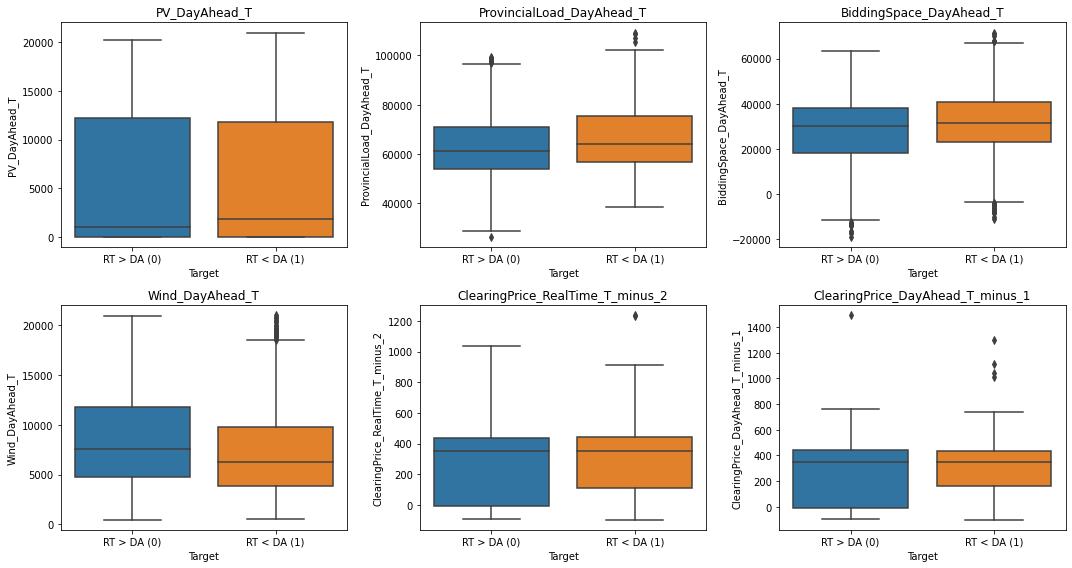

In [11]:
import math

n = len(major_cols)
ncols = 3                       # choose how many columns of subplots you want
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()           # make indexing easy

for i, col in enumerate(major_cols):
    sns.boxplot(data=train_eda2, x="target_label", y=col, ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(col)

# remove empty subplot panels if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Boxplot Summary

1. **Median differences:**  
   The `RT < DA` class shows slightly higher medians for `PV_DayAhead_T`, `ProvincialLoad_DayAhead_T`, and `BiddingSpace_DayAhead_T`. In contrast, `Wind_DayAhead_T` has a lower median for the `RT < DA` class.

2. **Class shifts:**  
   The clearest distribution shifts appear in `ProvincialLoad_DayAhead_T`, `BiddingSpace_DayAhead_T`, and `Wind_DayAhead_T`. However, the shifts are moderate rather than strongly separated.

3. **Distribution overlap:**  
   All selected features show substantial overlap between the two target classes. This indicates that no single raw variable is sufficient to separate the classes, motivating feature engineering and nonlinear models.

4. **Outliers:**  
   Both clearing price variables contain high-value outliers. Additional outliers are also visible in load and bidding-space variables, suggesting that robust validation and tree-based models may be helpful.


The selected features show weak-to-moderate class-dependent differences, especially in load, bidding space, wind, and recent price variables. However, the strong overlap between target classes suggests that no single raw feature can reliably separate the outcomes. This motivates using engineered features and nonlinear models to capture interactions across market conditions and time-of-day effects.

### 3.4 EDA: Feature Hourly distributions by target

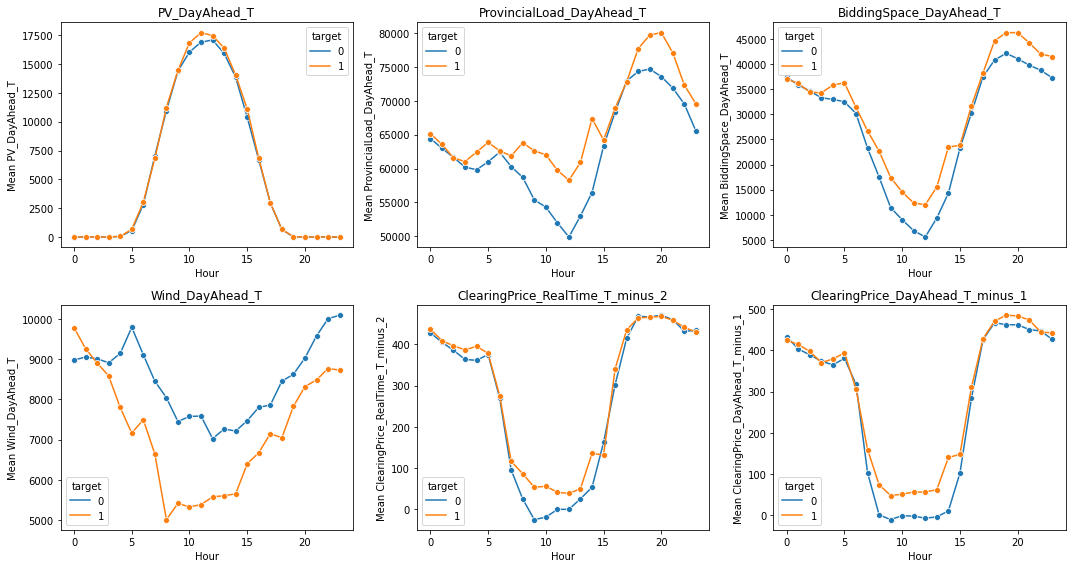

In [12]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

grouped = (
    train_eda
    .groupby(["hour", "target"])[major_cols]
    .mean()
    .reset_index()
)

n = len(major_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(major_cols):
    sns.lineplot(
        data=grouped,
        x="hour",
        y=col,
        hue="target",
        marker="o",
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Hour")
    axes[i].set_ylabel(f"Mean {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Feature Hourly Distribution Summary

- The selected features show strong intraday structure, meaning their values vary substantially by hour.
- Because the baseline level of each feature changes throughout the day, a feature’s predictive usefulness cannot be judged only from its global distribution.
- The same feature value may have different meaning depending on the hour. For example, a certain level of load or bidding space may be unusually high at one hour but normal at another.
- Class differences are often clearer within specific hours than in the overall distribution, suggesting that time-aware features and feature interactions are important.
- These patterns support including hour-based features and using nonlinear models that can capture interactions between market variables and time of day.

---
## 4. Data Transformation

In [13]:
class DataTransformer(object):
    def __init__(self):
        self.col_map = {
            "光伏_日前(T)": "PV_DayAhead_T",
            "省调负荷_日前(T)": "ProvincialLoad_DayAhead_T",
            "竞价空间_日前(T)": "BiddingSpace_DayAhead_T",
            "联络线计划日_日前(T)": "InterconnectionPlan_DayAhead_T",
            "非市场化机组出力_日前(T)": "NonMarketUnitOutput_DayAhead_T",
            "风力_日前(T)": "Wind_DayAhead_T",
            "光伏_实时(T-2)": "PV_RealTime_T_minus_2",
            "省调负荷_实时(T-2)": "ProvincialLoad_RealTime_T_minus_2",
            "竞价空间_实时(T-2)": "BiddingSpace_RealTime_T_minus_2",
            "联络线计划日_实时(T-2)": "Interconnection_RealTime_T_minus_2",
            "非市场化机组出力_实时(T-2)": "NonMarketUnitOutput_RealTime_T_minus_2",
            "风力_实时(T-2)": "Wind_RealTime_T_minus_2",
            "出清价格_实时(T-2)": "ClearingPrice_RealTime_T_minus_2",
            "出清价格_日前(T-1)": "ClearingPrice_DayAhead_T_minus_1"
        }
        self.target_map = {"搏低价": "BetLowPrice"}
        
    def fit(self, X, y=None):
        # nothing to learn here, but keep fit for sklearn-style API
        return self
    
    def transform(self, X, y=None):
        df = X.copy()
        df = df.rename(columns=self.col_map)
        
        if y is not None:
            y = y.copy().rename(columns=self.target_map)
            df["target"] = y["BetLowPrice"].values
            
        return df
    
    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X, y)
        
            

In [14]:
Tf = DataTransformer()
train_tf = Tf.fit_transform(train_raw, labels)

## 5. Featurization & Modeling

In [15]:
import numpy as np
def build_features(df):
    """Full improved feature set."""
    df = df.copy()
    X = pd.DataFrame(index=df.index)

    # Time
    hour = df.index.hour
    X["hour"] = hour
    X["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    X["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    X["dayofweek"] = df.index.dayofweek
    X["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
    # X["month"] = df.index.month

    # All raw features
    raw_cols = [
        "PV_DayAhead_T", "ProvincialLoad_DayAhead_T", "BiddingSpace_DayAhead_T",
        "InterconnectionPlan_DayAhead_T", "NonMarketUnitOutput_DayAhead_T",
        "Wind_DayAhead_T", "PV_RealTime_T_minus_2", "ProvincialLoad_RealTime_T_minus_2",
        "BiddingSpace_RealTime_T_minus_2", "Interconnection_RealTime_T_minus_2",
        "NonMarketUnitOutput_RealTime_T_minus_2", "Wind_RealTime_T_minus_2",
        "ClearingPrice_RealTime_T_minus_2", "ClearingPrice_DayAhead_T_minus_1",
    ]
    X[raw_cols] = df[raw_cols]

    # Safe 24h ramps (not cross-row .diff())
    for col in ["PV_DayAhead_T", "Wind_DayAhead_T",
                "ProvincialLoad_DayAhead_T", "BiddingSpace_DayAhead_T"]:
        X[f"{col}_ramp_24h"] = df[col] - df[col].shift(24)
        X[f"{col}_ramp_48h"] = df[col] - df[col].shift(48)

    # Price lags (same-hour lookback)
    for lag_days in [1, 2, 3, 7]:
        X[f"price_rt2_lag_{lag_days}d"] = df["ClearingPrice_RealTime_T_minus_2"].shift(lag_days * 24)
        X[f"price_da1_lag_{lag_days}d"] = df["ClearingPrice_DayAhead_T_minus_1"].shift(lag_days * 24)

    # Rolling price mean (3d, 7d) - shifted 1 day to avoid leakage
    price_shifted = df["ClearingPrice_RealTime_T_minus_2"].shift(24)
    X["price_rt2_roll3d"] = price_shifted.rolling(72, min_periods=1).mean()
    X["price_rt2_roll7d"] = price_shifted.rolling(168, min_periods=1).mean()

    # Price gap & context
    X["price_gap_recent"] = df["ClearingPrice_DayAhead_T_minus_1"] - df["ClearingPrice_RealTime_T_minus_2"]

    # Mismatch / forecast error features
    X["pv_diff_da_rt2"] = df["PV_DayAhead_T"] - df["PV_RealTime_T_minus_2"]
    X["wind_diff_da_rt2"] = df["Wind_DayAhead_T"] - df["Wind_RealTime_T_minus_2"]
    X["load_diff_da_rt2"] = df["ProvincialLoad_DayAhead_T"] - df["ProvincialLoad_RealTime_T_minus_2"]
    X["renewable_surplus_da"] = X["pv_diff_da_rt2"] + X["wind_diff_da_rt2"]

    # Residual demand
    X["residual_da"] = (
        df["ProvincialLoad_DayAhead_T"] - df["PV_DayAhead_T"]
        - df["Wind_DayAhead_T"] - df["NonMarketUnitOutput_DayAhead_T"]
    )

    # Hour × feature interactions
    for col in ["BiddingSpace_DayAhead_T", "PV_DayAhead_T",
                "Wind_DayAhead_T", "ProvincialLoad_DayAhead_T"]:
        X[f"{col}_x_sin"] = df[col] * X["sin_hour"]
        X[f"{col}_x_cos"] = df[col] * X["cos_hour"]

    # Missing value handling
    # For lag/ramp/rolling features, it forward-fills, 
    for col in X.columns:
        if "lag_" in col or "roll" in col or "ramp_" in col:
            X[col] = X[col].ffill()
    # then fills remaining missing values with the median.
    X = X.fillna(X.median(numeric_only=True))
    
    return X

In [16]:
train = build_features(train_tf)
train["target"] = labels["BetLowPrice"]

train = train.sort_index()

target = "target"
features = [c for c in train.columns if c != target]

print(train.shape)
print(train.index.min(), train.index.max())
train.head()

(2856, 52)
2025-04-03 00:00:00 2025-07-31 23:00:00


,hour,sin_hour,cos_hour,dayofweek,is_weekend,PV_DayAhead_T,ProvincialLoad_DayAhead_T,BiddingSpace_DayAhead_T,InterconnectionPlan_DayAhead_T,NonMarketUnitOutput_DayAhead_T,...,residual_da,BiddingSpace_DayAhead_T_x_sin,BiddingSpace_DayAhead_T_x_cos,PV_DayAhead_T_x_sin,PV_DayAhead_T_x_cos,Wind_DayAhead_T_x_sin,Wind_DayAhead_T_x_cos,ProvincialLoad_DayAhead_T_x_sin,ProvincialLoad_DayAhead_T_x_cos,target
datetime,,,,,,,,,,,,,,,,,,,,,
2025-04-03 00:00:00,0,0.000000,1.000000,3,0,18.0,57568.28,39575.94,11820.50,1582.0,...,51396.45,0.000000,39575.940000,0.000000,18.000000,0.000000,4571.830000,0.000000,57568.280000,0
2025-04-03 01:00:00,1,0.258819,0.965926,3,0,18.0,56082.60,38295.34,11451.50,1582.0,...,49746.83,9911.563331,36990.457933,4.658743,17.386665,1225.707469,4574.402550,14515.244979,54171.631745,0
2025-04-03 02:00:00,2,0.500000,0.866025,3,0,18.0,55159.24,37170.36,11445.25,1582.0,...,48615.62,18585.180000,32190.476028,9.000000,15.588457,2471.810000,4281.300507,27579.620000,47769.303093,0
2025-04-03 03:00:00,3,0.707107,0.707107,3,0,18.0,54814.82,36503.89,11414.25,1582.0,...,47918.14,25812.148159,25812.148159,12.727922,12.727922,3745.318346,3745.318346,38759.930932,38759.930932,0
2025-04-03 04:00:00,4,0.866025,0.500000,3,0,18.0,55456.70,36625.54,11387.00,1582.0,...,48012.53,31718.648067,18312.770000,15.588457,9.000000,5061.199684,2922.085000,48026.911010,27728.350000,0


### 5.1 Rolling Time-Series Validation
- the validation set is one future month
- the training set is all data before that month

In [17]:
def make_month_splits(df):
    """
    Expanding-window monthly splits.
    Example:
      train Apr -> valid May
      train Apr-May -> valid Jun
      train Apr-Jun -> valid Jul
    """
    splits = []

    # validation months we want
    valid_month_starts = [
        "2025-05-01",
        "2025-06-01",
        "2025-07-01",
    ]

    for val_start in valid_month_starts:
        val_start = pd.Timestamp(val_start)
        val_end = val_start + pd.offsets.MonthBegin(1)

        train_idx = df.index < val_start
        valid_idx = (df.index >= val_start) & (df.index < val_end)

        if train_idx.sum() > 0 and valid_idx.sum() > 0:
            splits.append({
                "train_start": df.index[train_idx].min(),
                "train_end": df.index[train_idx].max(),
                "valid_start": df.index[valid_idx].min(),
                "valid_end": df.index[valid_idx].max(),
                "train_idx": train_idx,
                "valid_idx": valid_idx,
            })

    return splits


splits = make_month_splits(train)

for i, s in enumerate(splits, 1):
    print(
        f"Split {i}: "
        f"train {s['train_start']} -> {s['train_end']} | "
        f"valid {s['valid_start']} -> {s['valid_end']}"
    )

Split 1: train 2025-04-03 00:00:00 -> 2025-04-30 23:00:00 | valid 2025-05-01 00:00:00 -> 2025-05-31 23:00:00
Split 2: train 2025-04-03 00:00:00 -> 2025-05-31 23:00:00 | valid 2025-06-01 00:00:00 -> 2025-06-30 23:00:00
Split 3: train 2025-04-03 00:00:00 -> 2025-06-30 23:00:00 | valid 2025-07-01 00:00:00 -> 2025-07-31 23:00:00


### 5.2 Train, Model, and Validate

In [18]:
# ── 1. Define new feature groups from build_features ──────────────────────

raw_cols = [
    "PV_DayAhead_T", "ProvincialLoad_DayAhead_T", "BiddingSpace_DayAhead_T",
    "InterconnectionPlan_DayAhead_T", "NonMarketUnitOutput_DayAhead_T",
    "Wind_DayAhead_T", "PV_RealTime_T_minus_2", "ProvincialLoad_RealTime_T_minus_2",
    "BiddingSpace_RealTime_T_minus_2", "Interconnection_RealTime_T_minus_2",
    "NonMarketUnitOutput_RealTime_T_minus_2", "Wind_RealTime_T_minus_2",
    "ClearingPrice_RealTime_T_minus_2", "ClearingPrice_DayAhead_T_minus_1",
]

time_cols = [
    "hour", "sin_hour", "cos_hour",
    "dayofweek", "is_weekend", #"month",
]

ramp_cols = [
    "PV_DayAhead_T_ramp_24h",    "PV_DayAhead_T_ramp_48h",
    "Wind_DayAhead_T_ramp_24h",  "Wind_DayAhead_T_ramp_48h",
    "ProvincialLoad_DayAhead_T_ramp_24h", "ProvincialLoad_DayAhead_T_ramp_48h",
    "BiddingSpace_DayAhead_T_ramp_24h",   "BiddingSpace_DayAhead_T_ramp_48h",
]

lag_cols = [
    "price_rt2_lag_1d", "price_rt2_lag_2d", "price_rt2_lag_3d", "price_rt2_lag_7d",
    "price_da1_lag_1d", "price_da1_lag_2d", "price_da1_lag_3d", "price_da1_lag_7d",
]

rolling_cols = [
    "price_rt2_roll3d", "price_rt2_roll7d",
]

price_cols = ["price_gap_recent"] + lag_cols + rolling_cols

mismatch_cols = [
    "pv_diff_da_rt2", "wind_diff_da_rt2", "load_diff_da_rt2",
    "renewable_surplus_da",
]

balance_cols = ["residual_da"]

interaction_cols = [
    "BiddingSpace_DayAhead_T_x_sin", "BiddingSpace_DayAhead_T_x_cos",
    "PV_DayAhead_T_x_sin",           "PV_DayAhead_T_x_cos",
    "Wind_DayAhead_T_x_sin",         "Wind_DayAhead_T_x_cos",
    "ProvincialLoad_DayAhead_T_x_sin","ProvincialLoad_DayAhead_T_x_cos",
]


# ── 2. Build feature sets to evaluate ────────────────────────────────────────

feature_sets = {
    "raw": raw_cols,
    "raw_time": raw_cols + time_cols,

    "raw_time_ramps": raw_cols + time_cols + ramp_cols,
    "raw_time_lags": raw_cols + time_cols + lag_cols,
    "raw_time_rolling": raw_cols + time_cols + rolling_cols,
    "raw_time_price": raw_cols + time_cols + price_cols,
    "raw_time_mismatch": raw_cols + time_cols + mismatch_cols,
    "raw_time_balance": raw_cols + time_cols + balance_cols,
    "raw_time_interact": raw_cols + time_cols + interaction_cols,

    "raw_time_price_ramps": raw_cols + time_cols + price_cols + ramp_cols,
    "raw_time_price_mismatch": raw_cols + time_cols + price_cols + mismatch_cols,
    "raw_time_price_interact": raw_cols + time_cols + price_cols + interaction_cols,

    "all": (
        raw_cols + time_cols + price_cols + ramp_cols
        + mismatch_cols + balance_cols + interaction_cols
    ),
}

#### Shared rolling-evaluation helper

In [19]:
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd

# --------- Shared evaluation function ----------
def eval_feature_set_rolling_model(
    df, 
    feature_cols, 
    splits, 
    model_builder, 
    model_name,
    fit_model=None
):
    """
    Generic expanding-window / rolling validation function.

    Parameters
    ----------
    df : DataFrame
        Training dataframe containing features and target.
    feature_cols : list
        Feature columns used for modeling.
    splits : list of dict
        Time-based split definitions.
    model_builder : function
        Function that returns a fresh model.
    model_name : str
        Name of the model.
    fit_model : function, optional
        Custom fit function for models that need validation data,
        such as LightGBM, XGBoost, and CatBoost with early stopping.
    """

    fold_rows = []

    for i, s in enumerate(splits, 1):
        train_part = df.loc[s["train_idx"]].copy()
        valid_part = df.loc[s["valid_idx"]].copy()

        X_train = train_part[feature_cols]
        y_train = train_part["target"]

        X_valid = valid_part[feature_cols]
        y_valid = valid_part["target"]

        model = model_builder()

        if fit_model is None:
            model.fit(X_train, y_train)
        else:
            fit_model(model, X_train, y_train, X_valid, y_valid)

        valid_pred_proba = model.predict_proba(X_valid)[:, 1]
        valid_pred = model.predict(X_valid)

        fold_rows.append({
            "model": model_name,
            "fold": i,
            "train_start": s["train_start"],
            "train_end": s["train_end"],
            "valid_start": s["valid_start"],
            "valid_end": s["valid_end"],
            "auc": roc_auc_score(y_valid, valid_pred_proba),
            "acc": accuracy_score(y_valid, valid_pred),
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "mean_auc": fold_df["auc"].mean(),
        "std_auc": fold_df["auc"].std(),
        "mean_acc": fold_df["acc"].mean(),
        "n_folds": len(fold_df),
    }

    return fold_df, summary


# ---------- Evaluate every feature set ----------
# This avoids repeating the same for name, cols in feature_sets.items() block for every model.
def evaluate_model_across_feature_sets(
    df,
    feature_sets,
    splits,
    model_builder,
    model_name,
    fit_model=None
):
    """
    Runs one model across all feature sets and returns:
    1. summary table by feature set
    2. fold-level table
    """

    summary_rows = []
    all_fold_rows = []

    for name, cols in feature_sets.items():
        cols = [c for c in cols if c in df.columns]

        fold_df, summary = eval_feature_set_rolling_model(
            df=df,
            feature_cols=cols,
            splits=splits,
            model_builder=model_builder,
            model_name=model_name,
            fit_model=fit_model
        )

        fold_df["feature_set"] = name
        fold_df["n_features"] = len(cols)
        all_fold_rows.append(fold_df)

        summary_rows.append({
            "model": model_name,
            "feature_set": name,
            "mean_auc": summary["mean_auc"],
            "std_auc": summary["std_auc"],
            "mean_acc": summary["mean_acc"],
            "n_features": len(cols),
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(["mean_auc", "std_auc"], ascending=[False, True])
        .reset_index(drop=True)
    )

    fold_results_df = pd.concat(all_fold_rows, ignore_index=True)

    return summary_df, fold_results_df

#### Logistic regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def build_logistic_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])


results_lr, folds_lr = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_logistic_model,
    model_name="LogisticRegression"
)

results_lr

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,LogisticRegression,raw_time_price_interact,0.551392,0.021595,0.536873,38
1,LogisticRegression,all,0.546634,0.015318,0.538411,51
2,LogisticRegression,raw_time_price,0.546057,0.007983,0.545624,30
3,LogisticRegression,raw_time_price_mismatch,0.545247,0.006583,0.543369,34
4,LogisticRegression,raw_time_lags,0.541423,0.018820,0.542473,27
5,LogisticRegression,raw_time_interact,0.540625,0.010435,0.541906,27
6,LogisticRegression,raw_time_price_ramps,0.536907,0.012793,0.544788,38
7,LogisticRegression,raw_time_rolling,0.536453,0.024552,0.551941,21
8,LogisticRegression,raw_time_balance,0.526868,0.000301,0.547581,20
9,LogisticRegression,raw_time,0.526858,0.000332,0.548029,19


#### LightGBM

In [21]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

def build_lgbm_model():
    return LGBMClassifier(
        n_estimators=1000,
        max_depth=4,
        num_leaves=15,
        learning_rate=0.02,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_samples=30,
        objective="binary",
        random_state=42,
        verbose=-1,
    )

def fit_lgbm_with_early_stopping(model, X_train, y_train, X_valid, y_valid):
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            early_stopping(stopping_rounds=50, verbose=False),
            log_evaluation(period=-1),
        ],
    )


results_lgbm, folds_lgbm = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_lgbm_model,
    model_name="LightGBM",
    fit_model=fit_lgbm_with_early_stopping
)

results_lgbm

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,LightGBM,raw_time_lags,0.596657,0.030356,0.477867,27
1,LightGBM,raw_time_interact,0.586630,0.076383,0.515427,27
2,LightGBM,raw_time,0.583214,0.060843,0.507228,19
3,LightGBM,raw_time_balance,0.582585,0.065739,0.577957,20
4,LightGBM,raw_time_mismatch,0.580985,0.054719,0.489068,23
5,LightGBM,all,0.579810,0.028921,0.560305,51
6,LightGBM,raw_time_price_mismatch,0.578929,0.019399,0.476971,34
7,LightGBM,raw_time_price,0.577325,0.046346,0.496879,30
8,LightGBM,raw_time_ramps,0.576339,0.063660,0.476971,27
9,LightGBM,raw_time_rolling,0.574996,0.016467,0.507064,21


#### XGBoost

In [22]:
from xgboost import XGBClassifier

def build_xgb_model():
    return XGBClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
    )

def fit_xgb_with_early_stopping(model, X_train, y_train, X_valid, y_valid):
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )


results_xgb, folds_xgb = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_xgb_model,
    model_name="XGBoost",
    fit_model=fit_xgb_with_early_stopping
)

results_xgb

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,XGBoost,raw_time_price_ramps,0.541403,0.062933,0.549223,38
1,XGBoost,all,0.539528,0.058051,0.552464,51
2,XGBoost,raw_time_price,0.532012,0.056874,0.544654,30
3,XGBoost,raw_time_ramps,0.531570,0.076734,0.572491,27
4,XGBoost,raw_time_price_mismatch,0.531367,0.055112,0.540666,34
5,XGBoost,raw_time,0.529236,0.081917,0.553763,19
6,XGBoost,raw_time_rolling,0.527284,0.069013,0.548701,21
7,XGBoost,raw_time_mismatch,0.525329,0.079916,0.546998,23
8,XGBoost,raw_time_lags,0.525149,0.072668,0.541801,27
9,XGBoost,raw_time_price_interact,0.524271,0.074728,0.549223,38


#### CatBoost

In [23]:
from catboost import CatBoostClassifier

def build_catboost_model():
    return CatBoostClassifier(
        iterations=1000,
        learning_rate=0.02,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )

def fit_catboost_with_early_stopping(model, X_train, y_train, X_valid, y_valid):
    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False,
    )


results_cat, folds_cat = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_catboost_model,
    model_name="CatBoost",
    fit_model=fit_catboost_with_early_stopping
)

results_cat

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,CatBoost,raw_time,0.606334,0.071867,0.559812,19
1,CatBoost,raw_time_price_interact,0.602022,0.040667,0.559827,38
2,CatBoost,raw_time_mismatch,0.598884,0.054840,0.567279,23
3,CatBoost,raw_time_lags,0.597431,0.068421,0.559737,27
4,CatBoost,raw_time_price,0.594038,0.050132,0.559050,30
5,CatBoost,raw,0.592321,0.039654,0.555227,14
6,CatBoost,raw_time_rolling,0.589921,0.059610,0.557602,21
7,CatBoost,raw_time_price_mismatch,0.588320,0.044809,0.579719,34
8,CatBoost,raw_time_balance,0.586908,0.036408,0.573193,20
9,CatBoost,raw_time_price_ramps,0.586414,0.052070,0.576807,38


#### Gradient Boosting

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

def build_gradient_boosting_model():
    return GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42,
    )


results_gb, folds_gb = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_gradient_boosting_model,
    model_name="GradientBoosting"
)

results_gb

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,GradientBoosting,raw_time_price_ramps,0.554033,0.047915,0.567100,38
1,GradientBoosting,raw_time_rolling,0.549415,0.050406,0.561066,21
2,GradientBoosting,all,0.545315,0.035042,0.559976,51
3,GradientBoosting,raw_time_ramps,0.543844,0.057428,0.557557,27
4,GradientBoosting,raw_time_balance,0.541024,0.093573,0.569265,20
5,GradientBoosting,raw_time_price_interact,0.535331,0.070639,0.552539,38
6,GradientBoosting,raw_time_price,0.534603,0.073956,0.553181,30
7,GradientBoosting,raw_time_mismatch,0.533821,0.079865,0.541383,23
8,GradientBoosting,raw_time_price_mismatch,0.533212,0.048760,0.544698,34
9,GradientBoosting,raw_time,0.532724,0.092162,0.565158,19


#### Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

def build_rf_model():
    return RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=30,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


results_rf, folds_rf = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_rf_model,
    model_name="RandomForest"
)

results_rf

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,RandomForest,all,0.595570,0.065501,0.595609,51
1,RandomForest,raw_time_price_interact,0.591168,0.066344,0.591697,38
2,RandomForest,raw_time_price_ramps,0.582031,0.066400,0.590293,38
3,RandomForest,raw_time_price_mismatch,0.575167,0.053224,0.579928,34
4,RandomForest,raw_time_price,0.573282,0.058997,0.584946,30
5,RandomForest,raw_time_interact,0.572619,0.072760,0.576912,27
6,RandomForest,raw_time_lags,0.570446,0.059411,0.576269,27
7,RandomForest,raw_time_ramps,0.561921,0.056754,0.582213,27
8,RandomForest,raw_time,0.557303,0.081903,0.580287,19
9,RandomForest,raw_time_rolling,0.550708,0.070004,0.569355,21


#### Extra Trees

In [26]:
from sklearn.ensemble import ExtraTreesClassifier

def build_extra_trees_model():
    return ExtraTreesClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=30,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


results_et, folds_et = evaluate_model_across_feature_sets(
    df=train,
    feature_sets=feature_sets,
    splits=splits,
    model_builder=build_extra_trees_model,
    model_name="ExtraTrees"
)

results_et

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,ExtraTrees,raw_time_price_interact,0.553416,0.068530,0.561320,38
1,ExtraTrees,raw_time_interact,0.550840,0.062534,0.572581,27
2,ExtraTrees,raw_time_price_ramps,0.544998,0.069882,0.570341,38
3,ExtraTrees,raw_time_ramps,0.544612,0.071250,0.574253,27
4,ExtraTrees,all,0.544123,0.063656,0.558901,51
5,ExtraTrees,raw_time_price,0.543238,0.071318,0.563172,30
6,ExtraTrees,raw_time_lags,0.541726,0.078042,0.569818,27
7,ExtraTrees,raw_time,0.539730,0.074099,0.566697,19
8,ExtraTrees,raw_time_rolling,0.538521,0.078877,0.566667,21
9,ExtraTrees,raw_time_balance,0.538321,0.070730,0.566667,20


### 5.3 Model Comparison

In [27]:
all_model_results = pd.concat(
    [
        results_lr,
        results_lgbm,
        results_xgb,
        results_cat,
        results_gb,
        results_rf,
        results_et,
    ],
    ignore_index=True
)

all_model_results = (
    all_model_results
    .sort_values(["mean_auc", "std_auc"], ascending=[False, True])
    .reset_index(drop=True)
)

all_model_results.head(10)

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,CatBoost,raw_time,0.606334,0.071867,0.559812,19
1,CatBoost,raw_time_price_interact,0.602022,0.040667,0.559827,38
2,CatBoost,raw_time_mismatch,0.598884,0.054840,0.567279,23
3,CatBoost,raw_time_lags,0.597431,0.068421,0.559737,27
4,LightGBM,raw_time_lags,0.596657,0.030356,0.477867,27
5,RandomForest,all,0.595570,0.065501,0.595609,51
6,CatBoost,raw_time_price,0.594038,0.050132,0.559050,30
7,CatBoost,raw,0.592321,0.039654,0.555227,14
8,RandomForest,raw_time_price_interact,0.591168,0.066344,0.591697,38
9,CatBoost,raw_time_rolling,0.589921,0.059610,0.557602,21


In [28]:
best_by_model = (
    all_model_results
    .sort_values(["model", "mean_auc", "std_auc"], ascending=[True, False, True])
    .groupby("model")
    .head(1)
    .sort_values("mean_auc", ascending=False)
    .reset_index(drop=True)
)

best_by_model

,model,feature_set,mean_auc,std_auc,mean_acc,n_features
0,CatBoost,raw_time,0.606334,0.071867,0.559812,19
1,LightGBM,raw_time_lags,0.596657,0.030356,0.477867,27
2,RandomForest,all,0.595570,0.065501,0.595609,51
3,GradientBoosting,raw_time_price_ramps,0.554033,0.047915,0.567100,38
4,ExtraTrees,raw_time_price_interact,0.553416,0.068530,0.561320,38
5,LogisticRegression,raw_time_price_interact,0.551392,0.021595,0.536873,38
6,XGBoost,raw_time_price_ramps,0.541403,0.062933,0.549223,38


### 5.4. Hyperparameter Tuning for Top Models
After comparing several model families, I selected the strongest validation performers for a small hyperparameter-tuning experiment.

In [29]:
# Generic tuning helper

from itertools import product
import pandas as pd

def make_param_grid(param_grid):
    """
    Converts a parameter grid dictionary into a list of parameter dictionaries.
    
    Example:
    {"max_depth": [3, 4], "learning_rate": [0.02, 0.03]}
    becomes:
    [
        {"max_depth": 3, "learning_rate": 0.02},
        {"max_depth": 3, "learning_rate": 0.03},
        {"max_depth": 4, "learning_rate": 0.02},
        {"max_depth": 4, "learning_rate": 0.03},
    ]
    """
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    return [
        dict(zip(keys, combo))
        for combo in product(*values)
    ]


def tune_model_on_feature_set(
    df,
    feature_cols,
    splits,
    model_name,
    model_builder_from_params,
    param_grid,
    fit_model=None
):
    """
    Runs rolling validation for each hyperparameter combination
    on one selected feature set.
    """

    tuning_rows = []
    param_list = make_param_grid(param_grid)

    for params in param_list:
        def model_builder():
            return model_builder_from_params(params)

        fold_df, summary = eval_feature_set_rolling_model(
            df=df,
            feature_cols=feature_cols,
            splits=splits,
            model_builder=model_builder,
            model_name=model_name,
            fit_model=fit_model
        )

        row = {
            "model": model_name,
            "mean_auc": summary["mean_auc"],
            "std_auc": summary["std_auc"],
            "mean_acc": summary["mean_acc"],
            "n_features": len(feature_cols),
        }

        row.update(params)
        tuning_rows.append(row)

    tuning_results = (
        pd.DataFrame(tuning_rows)
        .sort_values(["mean_auc", "std_auc"], ascending=[False, True])
        .reset_index(drop=True)
    )

    return tuning_results

#### Tune CatBoost
Current best CatBoost feature set: `raw_time`

In [30]:
cat_feature_set = "raw_time"
cat_cols = [c for c in feature_sets[cat_feature_set] if c in train.columns]

cat_param_grid = {
    "depth": [3, 4, 5],
    "learning_rate": [0.01, 0.02, 0.03],
    "l2_leaf_reg": [1, 3, 5],
}

def build_catboost_from_params(params):
    return CatBoostClassifier(
        iterations=1000,
        learning_rate=params["learning_rate"],
        depth=params["depth"],
        l2_leaf_reg=params["l2_leaf_reg"],
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    )

cat_tuning_results = tune_model_on_feature_set(
    df=train,
    feature_cols=cat_cols,
    splits=splits,
    model_name="CatBoost",
    model_builder_from_params=build_catboost_from_params,
    param_grid=cat_param_grid,
    fit_model=fit_catboost_with_early_stopping
)

cat_tuning_results

,model,mean_auc,std_auc,mean_acc,n_features,depth,learning_rate,l2_leaf_reg
0,CatBoost,0.606334,0.071867,0.559812,19,4,0.02,3
1,CatBoost,0.604260,0.066957,0.565845,19,4,0.01,3
2,CatBoost,0.603231,0.070887,0.563082,19,4,0.01,5
3,CatBoost,0.601078,0.076061,0.558901,19,4,0.02,5
4,CatBoost,0.597277,0.075023,0.546894,19,3,0.03,3
5,CatBoost,0.596384,0.074721,0.570953,19,4,0.03,1
6,CatBoost,0.595149,0.060042,0.534379,19,3,0.01,3
7,CatBoost,0.592454,0.080066,0.557467,19,4,0.03,3
8,CatBoost,0.590549,0.075141,0.546879,19,3,0.02,3
9,CatBoost,0.588878,0.039330,0.570953,19,5,0.02,3


#### Tune LightGBM
Current best LightGBM feature set: `raw_time_lags`

In [31]:
lgbm_feature_set = "raw_time_lags"
lgbm_cols = [c for c in feature_sets[lgbm_feature_set] if c in train.columns]

lgbm_param_grid = {
    "learning_rate": [0.01, 0.02, 0.03],
    "max_depth": [3, 4],
    "num_leaves": [7, 15],
    "min_child_samples": [30, 50],
    "reg_lambda": [1.0, 2.0],
}

def build_lgbm_from_params(params):
    return LGBMClassifier(
        n_estimators=1000,
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        reg_lambda=params["reg_lambda"],
        reg_alpha=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        random_state=42,
        verbose=-1,
    )

lgbm_tuning_results = tune_model_on_feature_set(
    df=train,
    feature_cols=lgbm_cols,
    splits=splits,
    model_name="LightGBM",
    model_builder_from_params=build_lgbm_from_params,
    param_grid=lgbm_param_grid,
    fit_model=fit_lgbm_with_early_stopping
)

lgbm_tuning_results

,model,mean_auc,std_auc,mean_acc,n_features,learning_rate,max_depth,num_leaves,min_child_samples,reg_lambda
0,LightGBM,0.616325,0.042428,0.510872,27,0.02,3,7,50,1.0
1,LightGBM,0.615481,0.043657,0.501613,27,0.02,3,15,50,1.0
2,LightGBM,0.610073,0.043566,0.507168,27,0.01,3,15,50,1.0
3,LightGBM,0.609948,0.043480,0.501150,27,0.01,3,7,50,1.0
4,LightGBM,0.609279,0.022334,0.549432,27,0.02,3,7,30,1.0
5,LightGBM,0.608293,0.044023,0.513560,27,0.02,3,15,50,2.0
6,LightGBM,0.608236,0.044089,0.512171,27,0.02,3,7,50,2.0
7,LightGBM,0.606846,0.049044,0.512171,27,0.03,3,7,50,2.0
8,LightGBM,0.606329,0.043643,0.508602,27,0.03,3,7,50,1.0
9,LightGBM,0.605845,0.050183,0.545042,27,0.03,3,15,50,2.0


#### Tune Random Forest
Current best Random Forest feature set: `all`

In [33]:
rf_feature_set = "all"
rf_cols = [c for c in feature_sets[rf_feature_set] if c in train.columns]

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [4, 5, 6, None],
    "min_samples_leaf": [10, 20, 30],
    "max_features": ["sqrt", 0.5],
}

def build_rf_from_params(params):
    return RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

rf_tuning_results = tune_model_on_feature_set(
    df=train,
    feature_cols=rf_cols,
    splits=splits,
    model_name="RandomForest",
    model_builder_from_params=build_rf_from_params,
    param_grid=rf_param_grid
)

rf_tuning_results

,model,mean_auc,std_auc,mean_acc,n_features,n_estimators,max_depth,min_samples_leaf,max_features
0,RandomForest,0.597705,0.064160,0.593907,51,300,4.0,30,sqrt
1,RandomForest,0.596408,0.061150,0.587918,51,500,4.0,30,sqrt
2,RandomForest,0.595724,0.065793,0.592055,51,300,5.0,30,sqrt
3,RandomForest,0.595570,0.065501,0.595609,51,500,5.0,30,sqrt
4,RandomForest,0.594064,0.059571,0.586962,51,300,5.0,20,sqrt
5,RandomForest,0.593856,0.052725,0.589307,51,500,5.0,20,sqrt
6,RandomForest,0.593265,0.050948,0.584782,51,300,6.0,20,sqrt
7,RandomForest,0.592050,0.061756,0.594698,51,500,NaN,30,sqrt
8,RandomForest,0.590791,0.056739,0.585155,51,500,4.0,20,sqrt
9,RandomForest,0.590758,0.065689,0.591965,51,500,6.0,30,sqrt


#### Combine tuning results

In [34]:
all_tuning_results = pd.concat(
    [
        cat_tuning_results.assign(feature_set=cat_feature_set),
        lgbm_tuning_results.assign(feature_set=lgbm_feature_set),
        rf_tuning_results.assign(feature_set=rf_feature_set),
    ],
    ignore_index=True
)

all_tuning_results = (
    all_tuning_results
    .sort_values(["mean_auc", "std_auc"], ascending=[False, True])
    .reset_index(drop=True)
)

all_tuning_results

,model,mean_auc,std_auc,mean_acc,n_features,depth,learning_rate,l2_leaf_reg,feature_set,max_depth,num_leaves,min_child_samples,reg_lambda,n_estimators,min_samples_leaf,max_features
0,LightGBM,0.616325,0.042428,0.510872,27,NaN,0.02,NaN,raw_time_lags,3.0,7.0,50.0,1.0,NaN,NaN,NaN
1,LightGBM,0.615481,0.043657,0.501613,27,NaN,0.02,NaN,raw_time_lags,3.0,15.0,50.0,1.0,NaN,NaN,NaN
2,LightGBM,0.610073,0.043566,0.507168,27,NaN,0.01,NaN,raw_time_lags,3.0,15.0,50.0,1.0,NaN,NaN,NaN
3,LightGBM,0.609948,0.043480,0.501150,27,NaN,0.01,NaN,raw_time_lags,3.0,7.0,50.0,1.0,NaN,NaN,NaN
4,LightGBM,0.609279,0.022334,0.549432,27,NaN,0.02,NaN,raw_time_lags,3.0,7.0,30.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,CatBoost,0.570693,0.071966,0.568175,19,3.0,0.01,1.0,raw_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,RandomForest,0.569931,0.059102,0.567025,51,NaN,NaN,NaN,all,NaN,NaN,NaN,NaN,500.0,10.0,sqrt
120,RandomForest,0.568586,0.060039,0.566473,51,NaN,NaN,NaN,all,NaN,NaN,NaN,NaN,300.0,10.0,sqrt
121,RandomForest,0.567755,0.063742,0.570669,51,NaN,NaN,NaN,all,5.0,NaN,NaN,NaN,300.0,10.0,0.5


In [35]:
best_tuned_by_model = (
    all_tuning_results
    .sort_values(["model", "mean_auc", "std_auc"], ascending=[True, False, True])
    .groupby("model")
    .head(1)
    .sort_values("mean_auc", ascending=False)
    .reset_index(drop=True)
)

best_tuned_by_model

,model,mean_auc,std_auc,mean_acc,n_features,depth,learning_rate,l2_leaf_reg,feature_set,max_depth,num_leaves,min_child_samples,reg_lambda,n_estimators,min_samples_leaf,max_features
0,LightGBM,0.616325,0.042428,0.510872,27,NaN,0.02,NaN,raw_time_lags,3.0,7.0,50.0,1.0,NaN,NaN,NaN
1,CatBoost,0.606334,0.071867,0.559812,19,4.0,0.02,3.0,raw_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RandomForest,0.597705,0.064160,0.593907,51,NaN,NaN,NaN,all,4.0,NaN,NaN,NaN,300.0,30.0,sqrt


In [36]:
baseline_top_models = best_by_model[
    best_by_model["model"].isin(["CatBoost", "LightGBM", "RandomForest"])
].copy()

baseline_top_models = baseline_top_models.rename(columns={
    "mean_auc": "baseline_mean_auc",
    "std_auc": "baseline_std_auc",
    "mean_acc": "baseline_mean_acc",
})

tuned_top_models = best_tuned_by_model.rename(columns={
    "mean_auc": "tuned_mean_auc",
    "std_auc": "tuned_std_auc",
    "mean_acc": "tuned_mean_acc",
})

comparison_tuning = baseline_top_models.merge(
    tuned_top_models,
    on=["model"],
    suffixes=("_baseline", "_tuned")
)

comparison_tuning["auc_change"] = (
    comparison_tuning["tuned_mean_auc"] 
    - comparison_tuning["baseline_mean_auc"]
)

comparison_tuning = comparison_tuning[
    [
        "model",
        "feature_set_baseline",
        "feature_set_tuned",
        "baseline_mean_auc",
        "tuned_mean_auc",
        "auc_change",
        "baseline_std_auc",
        "tuned_std_auc",
    ]
].sort_values("tuned_mean_auc", ascending=False)

comparison_tuning

,model,feature_set_baseline,feature_set_tuned,baseline_mean_auc,tuned_mean_auc,auc_change,baseline_std_auc,tuned_std_auc
1,LightGBM,raw_time_lags,raw_time_lags,0.596657,0.616325,0.019668,0.030356,0.042428
0,CatBoost,raw_time,raw_time,0.606334,0.606334,0.000000,0.071867,0.071867
2,RandomForest,all,all,0.595570,0.597705,0.002135,0.065501,0.064160


Hyperparameter tuning produced modest improvements across the top models. The clearest gain came from **LightGBM**, which improved from **0.597** to **0.616 mean validation ROC-AUC** using a shallower and more regularized configuration. CatBoost showed no meaningful improvement, suggesting that its baseline configuration was already close to optimal within the tested search space. Random Forest improved only slightly and remained below the tuned LightGBM in ROC-AUC.

The final tuned LightGBM model achieved the strongest validation performance, but the relatively small improvement shows that model performance is limited more by feature signal and temporal instability than by hyperparameter choice alone.

In [37]:
lgbm_feature_set = "raw_time_lags"
lgbm_cols = [c for c in feature_sets[lgbm_feature_set] if c in train.columns]

lgbm_param_grid = {
    "n_estimators": [300,500,700,1000],
    "learning_rate": [0.01, 0.02, 0.03],
    "max_depth": [3, 4, 5],
    "num_leaves": [7, 15, 20],
    "min_child_samples": [30, 50, 70],
    "reg_alpha": [0.1, 0.3, 0.5],
    "reg_lambda": [1.0, 2.0],
}

def build_lgbm_from_params(params):
    return LGBMClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        reg_lambda=params["reg_lambda"],
        reg_alpha=params["reg_alpha"],
        subsample=0.8,
        colsample_bytree=0.8,
#         objective="binary",
        random_state=42,
        verbose=-1,
    )

lgbm_tuning_results = tune_model_on_feature_set(
    df=train,
    feature_cols=lgbm_cols,
    splits=splits,
    model_name="LightGBM",
    model_builder_from_params=build_lgbm_from_params,
    param_grid=lgbm_param_grid,
    fit_model=fit_lgbm_with_early_stopping
)

lgbm_tuning_results

,model,mean_auc,std_auc,mean_acc,n_features,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,reg_alpha,reg_lambda
0,LightGBM,0.616325,0.042428,0.510872,27,300,0.02,3,7,50,0.1,1.0
1,LightGBM,0.616325,0.042428,0.510872,27,500,0.02,3,7,50,0.1,1.0
2,LightGBM,0.616325,0.042428,0.510872,27,700,0.02,3,7,50,0.1,1.0
3,LightGBM,0.616325,0.042428,0.510872,27,1000,0.02,3,7,50,0.1,1.0
4,LightGBM,0.615823,0.041631,0.511111,27,300,0.02,3,7,50,0.3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1939,LightGBM,0.573989,0.015844,0.540860,27,1000,0.01,5,15,30,0.3,2.0
1940,LightGBM,0.573939,0.019691,0.542249,27,300,0.01,5,20,30,0.5,2.0
1941,LightGBM,0.573939,0.019691,0.542249,27,500,0.01,5,20,30,0.5,2.0
1942,LightGBM,0.573939,0.019691,0.542249,27,700,0.01,5,20,30,0.5,2.0


## 6. Train Final Model and Predict Test

In [38]:
test_raw = pd.read_csv("test.csv", parse_dates=True, index_col=0)
test_tf = Tf.transform(test_raw)
test = build_features(test_tf)

<Axes: >

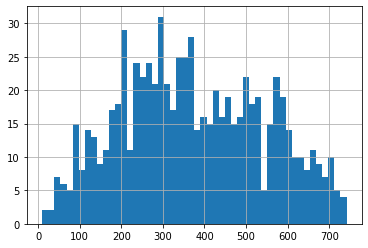

In [39]:
from scipy.stats import rankdata
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

top_sets = [
    "raw_time_lags",
    "raw_time_interact",
    "raw_time_price",
    "all",
]

preds = {}

for fs in top_sets:
    cols = [c for c in feature_sets[fs] if c in train.columns]

    X_full = train[cols]
    y_full = train["target"]
    X_test = test[cols]

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_full, y_full)
    preds[fs] = model.predict_proba(X_test)[:, 1]

# rank average
rank_preds = np.column_stack([rankdata(preds[k]) for k in top_sets])
final_pred = rank_preds.mean(axis=1)

submission = pd.DataFrame({
    "datetime": test.index,
    "搏低价": final_pred
})
# submission.to_csv("submission_A3_lgbm_rankblend.csv", index=False)
submission["搏低价"].hist(bins=50)

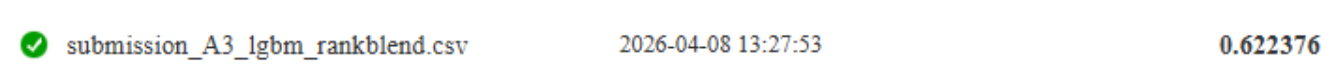